In [1]:
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "matplotlib", "seaborn", "scikit-learn"])

CompletedProcess(args=['pip', 'install', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn'], returncode=0)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
df = pd.read_csv("Iris.csv")

print("Shape of dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape of dataset: (150, 6)

First 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
print("\nLast 5 rows:")
df.tail()


Last 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica


In [5]:
print("\nRandom 10 Samples are:")
df.sample(10)


Random 10 Samples are:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
99,100,5.7,2.8,4.1,1.3,Iris-versicolor
40,41,5.0,3.5,1.3,0.3,Iris-setosa
114,115,5.8,2.8,5.1,2.4,Iris-virginica
130,131,7.4,2.8,6.1,1.9,Iris-virginica
23,24,5.1,3.3,1.7,0.5,Iris-setosa
25,26,5.0,3.0,1.6,0.2,Iris-setosa
70,71,5.9,3.2,4.8,1.8,Iris-versicolor
31,32,5.4,3.4,1.5,0.4,Iris-setosa
58,59,6.6,2.9,4.6,1.3,Iris-versicolor
44,45,5.1,3.8,1.9,0.4,Iris-setosa


In [6]:
print(df.columns.tolist())

['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']


In [7]:
# Drop the Id column as it's not useful
df = df.drop('Id', axis=1)

# Basic statistics
print("=== Dataset Summary ===")
print(df.describe())

print("\n=== Species Count ===")
print(df['Species'].value_counts())

print("\n=== Any Missing Values? ===")
print(df.isnull().sum())

=== Dataset Summary ===
       SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count     150.000000    150.000000     150.000000    150.000000
mean        5.843333      3.054000       3.758667      1.198667
std         0.828066      0.433594       1.764420      0.763161
min         4.300000      2.000000       1.000000      0.100000
25%         5.100000      2.800000       1.600000      0.300000
50%         5.800000      3.000000       4.350000      1.300000
75%         6.400000      3.300000       5.100000      1.800000
max         7.900000      4.400000       6.900000      2.500000

=== Species Count ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

=== Any Missing Values? ===
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


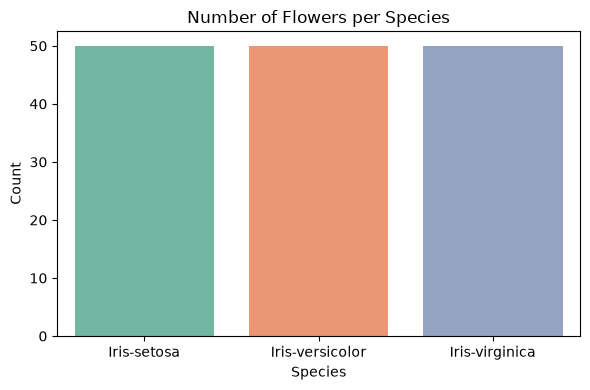

In [8]:
# Visualization of Data

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Species', palette='Set2')
plt.title('Number of Flowers per Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

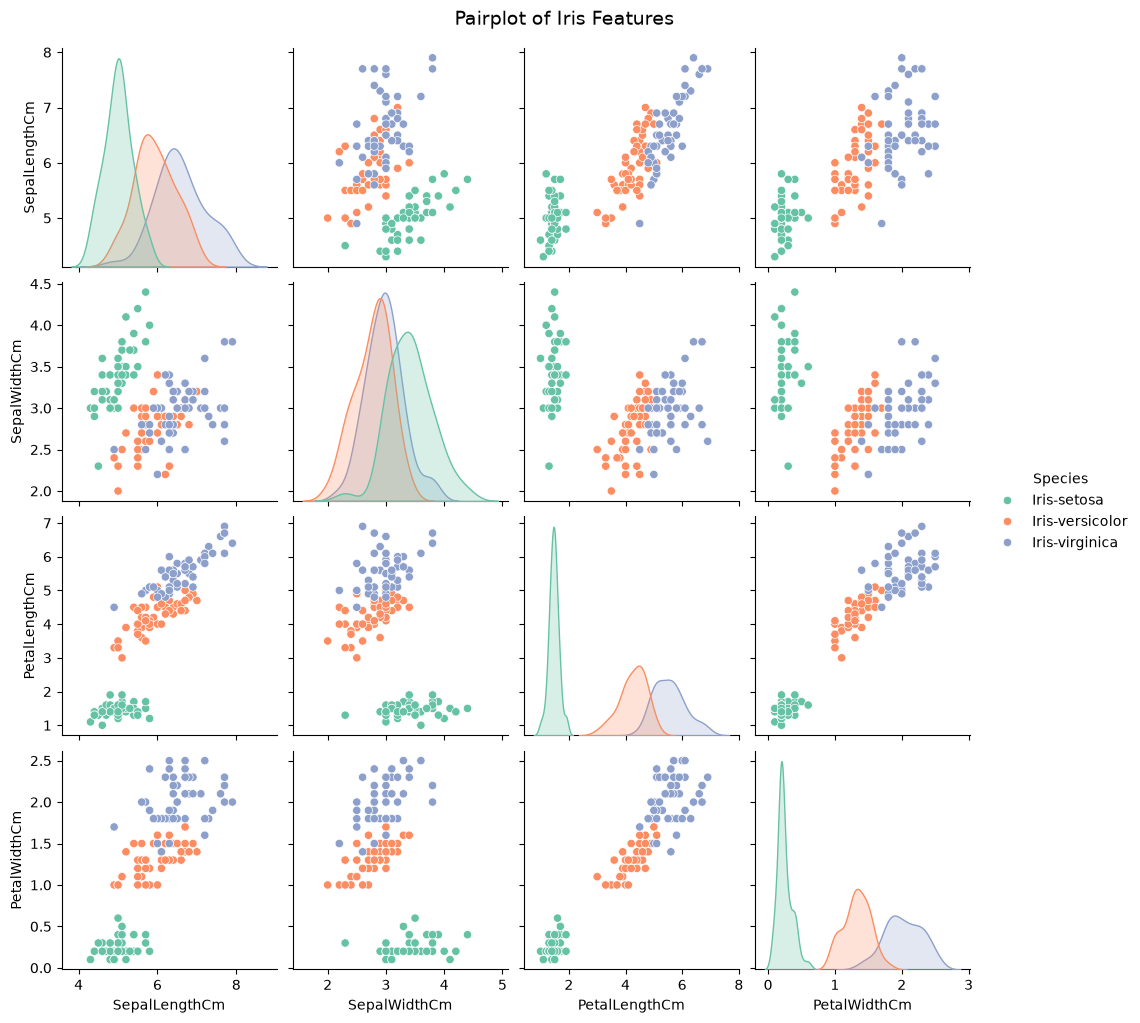

In [9]:
sns.pairplot(df, hue='Species', palette='Set2', diag_kind='kde')
plt.suptitle('Pairplot of Iris Features', y=1.02, fontsize=14)
plt.show()

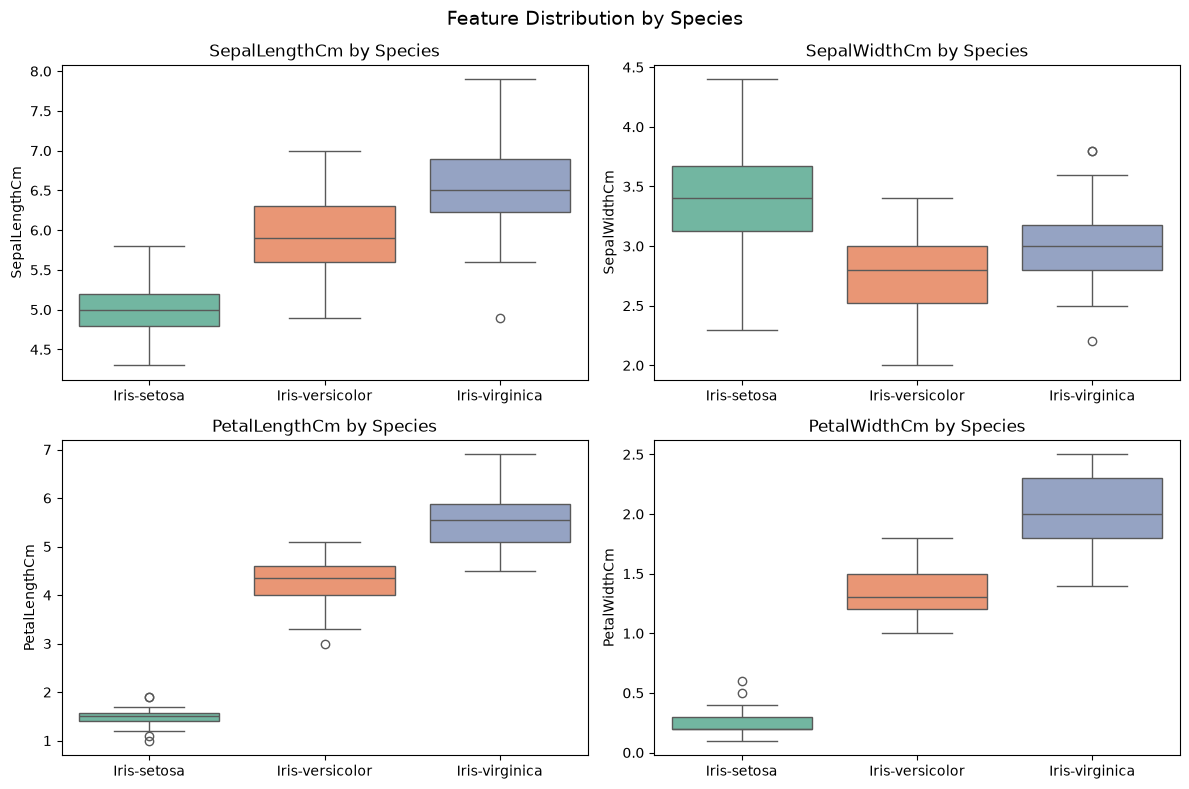

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(data=df, x='Species', y=feature, palette='Set2', ax=ax)
    ax.set_title(f'{feature} by Species')
    ax.set_xlabel('')

plt.suptitle('Feature Distribution by Species', fontsize=14)
plt.tight_layout()
plt.show()

In [11]:
# Split Data into Train & Test

X = df.drop('Species', axis=1)
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]}")
print(f"Testing samples  : {X_test.shape[0]}")

Training samples : 120
Testing samples  : 30


In [12]:
# Train the Model

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [13]:
# Evaluate the Model

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

print("=== Classification Report ===")
print(classification_report(y_test, y_pred))

Model Accuracy: 90.00%

=== Classification Report ===
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



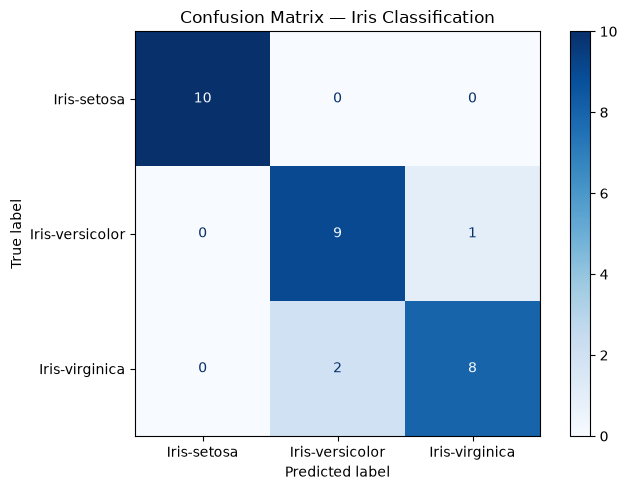

In [14]:
# CONFUSION MATRIX 

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=df['Species'].unique())

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix — Iris Classification')
plt.tight_layout()
plt.show()

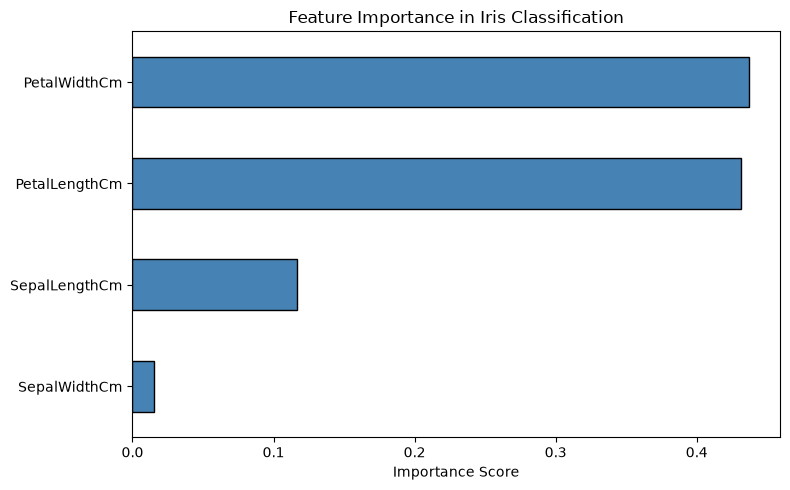


Top feature: PetalWidthCm


In [15]:
# feature importance 

importances = pd.Series(model.feature_importances_,
                        index=['SepalLengthCm', 'SepalWidthCm',
                               'PetalLengthCm', 'PetalWidthCm'])
importances_sorted = importances.sort_values()

plt.figure(figsize=(8, 5))
importances_sorted.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Feature Importance in Iris Classification')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop feature:", importances.idxmax())

In [16]:
# Predict a NEW FLOWER

new_flower = pd.DataFrame([[5.1, 3.5, 1.4, 0.2]],
                           columns=['SepalLengthCm', 'SepalWidthCm',
                                    'PetalLengthCm', 'PetalWidthCm'])
prediction = model.predict(new_flower)
probability = model.predict_proba(new_flower)

print(f"Predicted Species : {prediction[0]}")
print(f"Confidence        : {max(probability[0]) * 100:.1f}%")

Predicted Species : Iris-setosa
Confidence        : 100.0%
